In [ ]:
from google.colab import files
files.upload()

Saving Customer-Churn-Records.csv to Customer-Churn-Records (1).csv


{'Customer-Churn-Records (1).csv': b"RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned\r\n1,15634602,Hargrave,619,France,Female,42,2,0,1,1,1,101348.88,1,1,2,DIAMOND,464\r\n2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456\r\n3,15619304,Onio,502,France,Female,42,8,159660.8,3,1,0,113931.57,1,1,3,DIAMOND,377\r\n4,15701354,Boni,699,France,Female,39,1,0,2,0,0,93826.63,0,0,5,GOLD,350\r\n5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.1,0,0,5,GOLD,425\r\n6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484\r\n7,15592531,Bartlett,822,France,Male,50,7,0,2,1,1,10062.8,0,0,2,SILVER,206\r\n8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282\r\n9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.5,0,0,3,GOLD,251\r\n10,15592389,H?,684,France,Male,27,2,

In [ ]:
import pandas as pd

df = pd.read_csv("Customer-Churn-Records (1).csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
df.shape
df.sum()
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned'],
      dtype='object')

In [ ]:
df = df.drop([...], axis=1, errors='ignore')

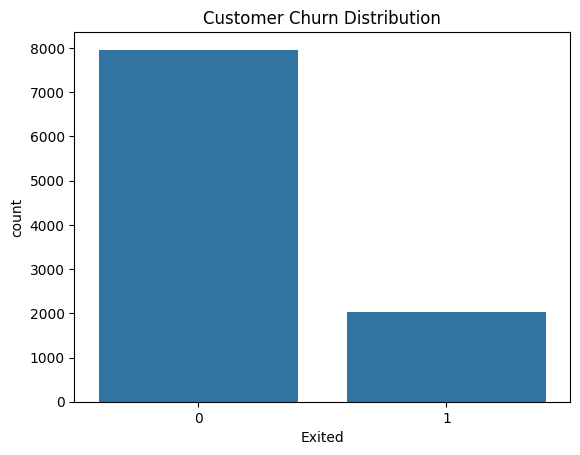

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object'):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


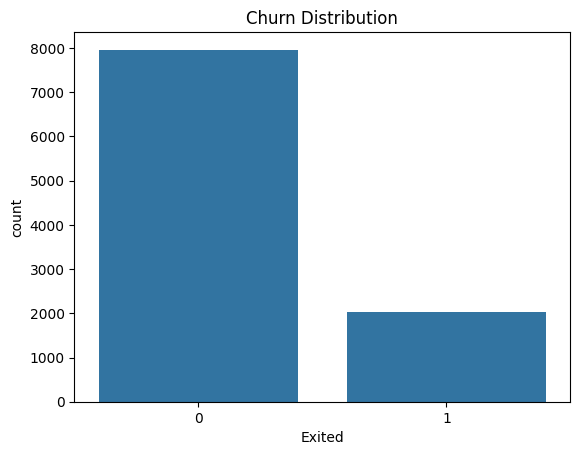

In [ ]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

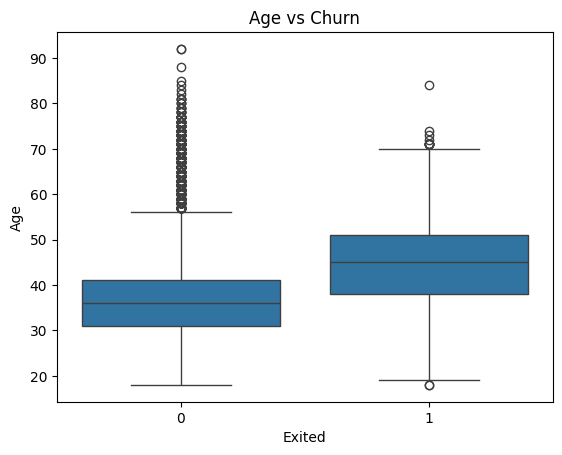

In [ ]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

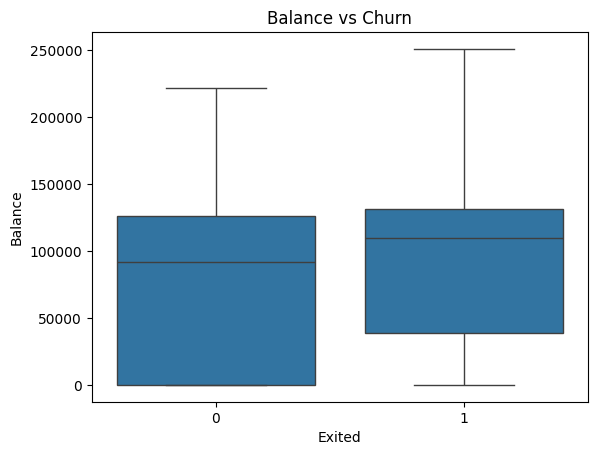

In [ ]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")
plt.show()

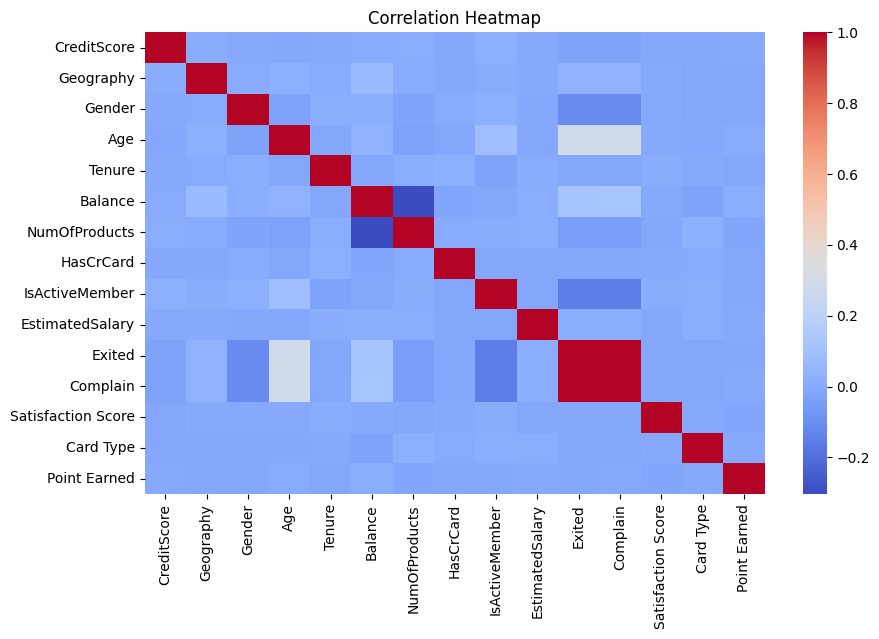

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic:", accuracy_score(y_test, pred_lr))
print("Decision Tree:", accuracy_score(y_test, pred_dt))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("KNN:", accuracy_score(y_test, pred_knn))
print("Naive Bayes:", accuracy_score(y_test, pred_nb))

Logistic: 0.794
Decision Tree: 0.9975
Random Forest: 0.9995
KNN: 0.999
Naive Bayes: 0.9995


In [ ]:
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

[[1589    1]
 [   0  410]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1590
           1       1.00      1.00      1.00       410

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

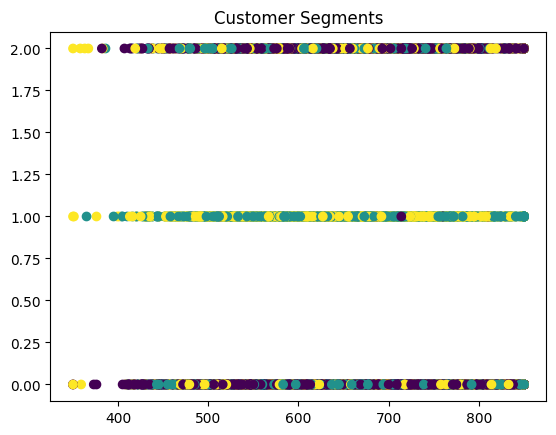

In [ ]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=df['Cluster'])
plt.title("Customer Segments")
plt.show()